In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_excel("customer_data.xlsx")

print(df.head())

  Cust  Age  Annual_Spend  Visits_Month  Basket_Size
0   C1   28          1200             8           12
1   C2   32          1500            10           15
2   C3   26           800             6            8
3   C4   29           950             7           10
4   C5   45          4500            22           35


In [19]:
# clean columns
df.columns = df.columns.str.strip().str.replace(" ", "_")
print(df.columns)

Index(['Cust', 'Age', 'Annual_Spend', 'Visits_Month', 'Basket_Size'], dtype='object')


In [20]:
# features to use for clustering
features = ["Age", "Annual_Spend", "Visits_Month", "Basket_Size"]
X = df[features].values

In [21]:

# Scale features (important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

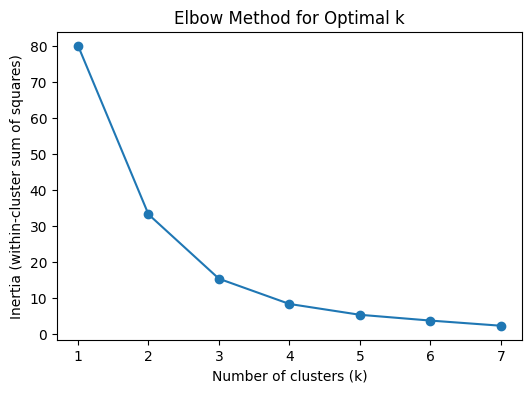

In [22]:
# use elbow method to choose K
inertias = []
K_range = range(1, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.show()

In [23]:
# run k-means and add cluster labels
k = 3  # or anything from the elbow plot

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
print(df[["Cust", "Cluster"] + features])

   Cust  Cluster  Age  Annual_Spend  Visits_Month  Basket_Size
0    C1        1   28          1200             8           12
1    C2        1   32          1500            10           15
2    C3        1   26           800             6            8
3    C4        1   29           950             7           10
4    C5        0   45          4500            22           35
5    C6        0   48          5200            25           42
6    C7        0   52          4800            24           38
7    C8        0   60          3200            18           28
8    C9        2   65          1800            12           20
9   C10        2   68          1400             9           16
10  C11        0   35          2200            15           22
11  C12        0   38          2600            17           25
12  C13        2   72           600             4            6
13  C14        2   75           450             3            5
14  C15        2   70           750             5      

In [24]:
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df["Cluster"] = range(k)
print(centers_df)

         Age  Annual_Spend  Visits_Month  Basket_Size  Cluster
0  46.875000   3600.000000     19.625000    30.750000        0
1  27.285714    935.714286      6.857143     9.428571        1
2  70.000000   1000.000000      6.600000    10.800000        2


In [29]:
# within clusters sum of squares
def cluster_wcss(X, labels, centers):
    wcss = {}
    for c in np.unique(labels):
        points = X[labels == c]
        center = centers[c]
        wcss[c] = np.sum((points - center)**2)
    return wcss

wcss_per_cluster = cluster_wcss(X_scaled, clusters, kmeans.cluster_centers_)
wcss_series = pd.Series(wcss_per_cluster, name="WCSS")
print(wcss_series)


0    10.110396
1     1.956019
2     3.320880
Name: WCSS, dtype: float64


In [30]:
# total variance between clusters
from scipy.spatial.distance import cdist

distances = cdist(centers_original, centers_original)
print(pd.DataFrame(distances))

             0            1            2
0     0.000000  2664.473631  2600.211995
1  2664.473631     0.000000    77.195273
2  2600.211995    77.195273     0.000000


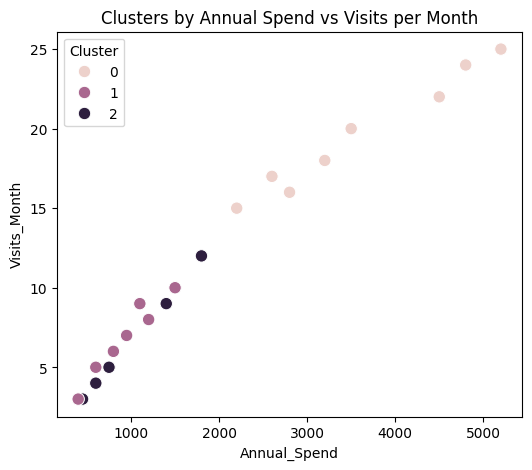

In [25]:
# visualize annual spend vs visits per month

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="Annual_Spend",
    y="Visits_Month",
    hue="Cluster",
    s=80
)
plt.title("Clusters by Annual Spend vs Visits per Month")
plt.legend(title="Cluster")
plt.show()

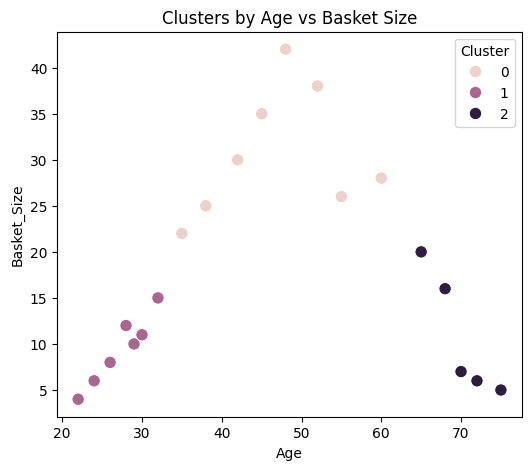

In [26]:
# visualize age vs basket size
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Basket_Size",
    hue="Cluster",
    s=80
)
plt.title("Clusters by Age vs Basket Size")
plt.legend(title="Cluster")
plt.show()

Explained variance ratio: [0.74774552 0.2476709 ]
Components (loadings):
          Age  Annual_Spend  Visits_Month  Basket_Size
PC1  0.075822      0.575119      0.574683     0.577259
PC2  0.996009     -0.032784     -0.081183    -0.017340


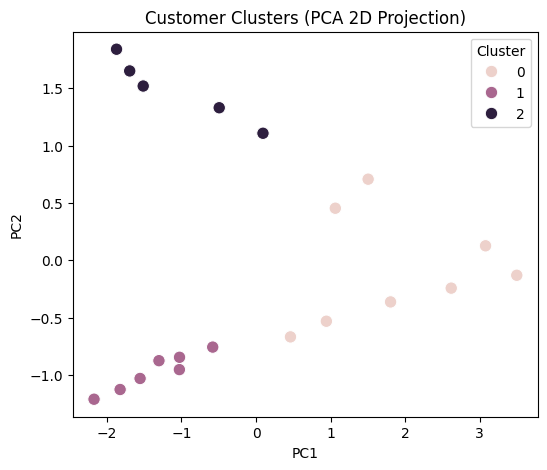

In [27]:
# visualize clusters with PCA (4 features into 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]
# explain the principal components
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Components (loadings):")
loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1", "PC2"]
)
print(loadings)
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=80
)
plt.title("Customer Clusters (PCA 2D Projection)")
plt.legend(title="Cluster")
plt.show()